## LIWC_Analysis.py

- Documents coded across three time periods: T0 (Pre-War Framing), T1 (Build-up (post Authorization for Use of Military Force Against Iraq)), T2 (Post-Invasion). Distribution: T0 n=163, T1 n=188, T2 n=185
- Statements coded as accurate or disputed based on the eventual finding that no active WMD programs were present in Iraq. Groups are imbalanced (accurate n=88, disputed n=404), reflecting the composition of the original dataset, not a sampling choice
- Prepared speech (speeches, official documents) and spontaneous speech (press briefings, interviews) analyzed separately per LIWC-22 guidance. Authenticity scoring is unreliable for prepared remarks
- All variables non-normally distributed. Non-parametric tests used throughout (Shapiro-Wilk confirmed, p < .05 across all groups)
- Kruskal-Wallis used as omnibus test for 3+ group comparisons; pairwise Mann-Whitney U with Benjamini-Hochberg correction applied where significant
- Results interpreted as stochastic dominance rather than median differences, since similar distribution shape between groups cannot be guaranteed
- Legislative documents excluded from institutional comparisons due to insufficient and structurally distinct data.
- Missing accuracy for first 45 documents to be expected. They are dropped from accuracy-based analysis.

In [4]:
import pandas as pd
import numpy as np
from scipy import stats
import matplotlib.pyplot as plt
import seaborn as sns
from itertools import combinations
from statsmodels.stats.multitest import multipletests


In [5]:
INPUT_CSV = "IraqLIWCCombined.csv"

# Core LIWC summary dimensions selected for analysis
CORE_VARS = ["Analytic", "Clout", "Authentic", "Tone", "moral", "power"]

In [6]:
# Load, check dimensions, recode missing data (very minimal in this dataset). Missing accuracy for first 45 documents to be expected.
df = pd.read_csv(INPUT_CSV, na_values=["", "NA", "N/A", "."])
print(f"Loaded {len(df)} rows, {df.shape[1]} columns\n")

Loaded 536 rows, 145 columns



## Order categorical variables to avoid alphabetic default order.
# Reference variables could be reconfigured for different interpretation.
# Results do not change.

In [7]:
df["time_period"] = pd.Categorical(
    df["time_period"],
    categories=["T0: Pre-War Framing", "T1: Build-up", "T2: Post-Invasion"],
    ordered=True
)
df["prepared"] = pd.Categorical(
    df["prepared"],
    categories=["prepared", "spontaneous", "legislative"],
    ordered=False
)
df["claim_accuracy"] = pd.Categorical(
    df["claim_accuracy"],
    categories=["accurate", "disputed"],
    ordered=False
)

## Flag short documents — LIWC percentage scores become unreliable
# below 100 words. Later testing will separate by wc_flag values.

In [8]:
df["wc_flag"] = np.select(
    [df["WC"] < 50, df["WC"] < 100],
    ["very_short",  "short"],
    default="adequate"
)
df["short_doc"] = df["WC"] < 100


## Check categorical distributions. Ensure adequate sampling for tests.
# Should be no unexpected NAs; manually investigate if any. (legislative dropped due to insufficient data collection)

In [9]:
for cat in ["time_period", "prepared", "claim_accuracy"]:
    print(f"{cat}:")
    print(df[cat].value_counts(dropna=False).sort_index(), "\n")

# Confirm all core variables present before continuing
missing = [v for v in CORE_VARS if v not in df.columns]
if missing:
    print(f"VARIABLES NOT FOUND: {missing}")
    CORE_VARS = [v for v in CORE_VARS if v in df.columns]

time_period:
time_period
T0: Pre-War Framing    163
T1: Build-up           188
T2: Post-Invasion      185
Name: count, dtype: int64 

prepared:
prepared
prepared       213
spontaneous    292
legislative     26
NaN              5
Name: count, dtype: int64 

claim_accuracy:
claim_accuracy
accurate     88
disputed    404
NaN          44
Name: count, dtype: int64 



## Shapiro-Wilk test per variable per document type.
#  p < .05 indicates non-normal distribution means non-parametric tests required through analysis.
# Minimum n=3 required for Shapiro-Wilk/ capped at 5000 observations.

In [10]:
results = []
for group, gdf in df[df["prepared"].notna()].groupby("prepared", observed=True):
    for var in CORE_VARS:
        col = gdf[var].dropna()
        if len(col) >= 3:
            stat, p = stats.shapiro(col[:5000])
        else:
            stat, p = np.nan, np.nan
        results.append({
            "prepared":  group,
            "variable":  var,
            "n":         len(col),
            "mean":      round(col.mean(), 2),
            "sd":        round(col.std(),  2),
            "skew":      round(float(stats.skew(col)), 2),
            "shapiro_p": round(p, 4) if not np.isnan(p) else np.nan
        })

normality_table = (
    pd.DataFrame(results)
    .sort_values(["variable", "prepared"])
    .reset_index(drop=True)
)
print("Normality table (Core Variables by Doc Type):")
print(normality_table.to_string(index=False), "\n")
print("Shapiro-Wilk p < .05 across all groups — non-parametric tests required.\n")

Normality table (Core Variables by Doc Type):
   prepared  variable   n  mean    sd  skew  shapiro_p
legislative  Analytic  26 71.21 13.69 -0.92     0.0742
   prepared  Analytic 213 59.99 24.08 -0.36     0.0000
spontaneous  Analytic 292 44.88 22.40  0.03     0.0139
legislative Authentic  26 38.26 13.23 -0.34     0.3889
   prepared Authentic 212 22.82 21.51  1.31     0.0000
spontaneous Authentic 292 40.19 23.59  0.52     0.0000
legislative     Clout  26 63.00 13.94 -0.17     0.3817
   prepared     Clout 213 75.10 22.04 -1.03     0.0000
spontaneous     Clout 292 61.71 22.95 -0.51     0.0000
legislative      Tone  26 22.42 14.74  1.11     0.0435
   prepared      Tone 213 20.47 24.50  1.35     0.0000
spontaneous      Tone 287 25.20 21.81  1.14     0.0000
legislative     moral  26  0.22  0.17  0.68     0.0707
   prepared     moral 213  0.41  0.57  1.87     0.0000
spontaneous     moral 292  0.19  0.36  2.57     0.0000
legislative     power  26  6.14  1.27  0.08     0.8091
   prepared     pow

## Stochastic Dominance Tests (Kruskal Wallis) (meaningful differences in scores across groups)

# Tests for stochastic dominance across categorical groupings/ whether the probability of observing higher or lower ranked LIWC scores differs significantly between groups. Interpreted as meaningful shifts in institutional rhetoric. Does not test for median difference, but if groups were independent of eachother, it could. Kruskal-Wallis used as test for 3+ group variables; pairwise Mann-Whitney U with Benjamini-Hochberg correction added where Kruskal-Wallis is significant.

# Note: prepared/spontaneous grouping is not valid for Authentic scoring. LIWC-22 flags authenticity as unreliable for prepared remarks since the metric assumes unscripted speech. This separates prepared and spontaneous data for time period and claim accuracy analysis. 

In [34]:
cat_vars_multi = {
    "time_period":    ["T0: Pre-War Framing", "T1: Build-up", "T2: Post-Invasion"],
    "prepared":       ["prepared", "spontaneous"],
    "claim_accuracy": ["accurate", "disputed"]
}

for cat, levels in cat_vars_multi.items():

    # For time_period and claim_accuracy, split by prepared/spontaneous
    if cat in ["time_period", "claim_accuracy"]:
        prep_splits = [("prepared", "prepared"), ("spontaneous", "spontaneous")]
    else:
        prep_splits = [(None, "all")]

    for prep_val, prep_label in prep_splits:
        if prep_val:
            df_cat = df[(df["prepared"] == prep_val) & (df[cat].isin(levels))].copy()
            print(f"GROUP: {cat.upper()} — {prep_label.upper()}")
        else:
            df_cat = df[df[cat].isin(levels)].copy()
            print(f"GROUP: {cat.upper()}")

        for level, grp in df_cat.groupby(cat, observed=True):
            print(f"  {level}: n={len(grp)}")

        for var in CORE_VARS:
            groups = [g[var].dropna().values
                      for _, g in df_cat.groupby(cat, observed=True)]

            if len(groups) == 2:
                stat, p = stats.mannwhitneyu(
                    groups[0], groups[1], alternative="two-sided"
                )
                sig = "***" if p < 0.001 else "**" if p < 0.01 else "*" if p < 0.05 else "ns"
                print(f"  {var}: U={stat:.1f}, p={p:.4f} {sig}")

            else:
                stat, p = stats.kruskal(*groups)
                print(f"\n  {var}, Kruskal Wallis: H={stat:.2f}, p={p:.4f}")
                if p < 0.05:
                    pairs  = list(combinations(levels, 2))
                    p_vals, labels = [], []
                    for a, b in pairs:
                        col_a = df_cat[df_cat[cat] == a][var].dropna()
                        col_b = df_cat[df_cat[cat] == b][var].dropna()
                        u, p_pair = stats.mannwhitneyu(
                            col_a, col_b, alternative="two-sided"
                        )
                        p_vals.append(p_pair)
                        labels.append(f"{a} vs {b}")
                    _, p_corrected, _, _ = multipletests(p_vals, method="fdr_bh")
                    for label, p_raw, p_adj in zip(labels, p_vals, p_corrected):
                        sig = "***" if p_adj < 0.001 else "**" if p_adj < 0.01 else "*" if p_adj < 0.05 else "ns"
                        print(f"    {label}: p_raw={p_raw:.4f}, p_adj={p_adj:.4f} {sig}")
                else:
                    print(f"    No significant group differences. No need for pairwise test.")

GROUP: TIME_PERIOD — PREPARED
  T0: Pre-War Framing: n=59
  T1: Build-up: n=75
  T2: Post-Invasion: n=79

  Analytic, Kruskal Wallis: H=11.30, p=0.0035
    T0: Pre-War Framing vs T1: Build-up: p_raw=0.6395, p_adj=0.6395 ns
    T0: Pre-War Framing vs T2: Post-Invasion: p_raw=0.0170, p_adj=0.0255 *
    T1: Build-up vs T2: Post-Invasion: p_raw=0.0013, p_adj=0.0040 **

  Clout, Kruskal Wallis: H=4.03, p=0.1335
    No significant group differences. No need for pairwise test.

  Authentic, Kruskal Wallis: H=13.42, p=0.0012
    T0: Pre-War Framing vs T1: Build-up: p_raw=0.0859, p_adj=0.0859 ns
    T0: Pre-War Framing vs T2: Post-Invasion: p_raw=0.0515, p_adj=0.0772 ns
    T1: Build-up vs T2: Post-Invasion: p_raw=0.0004, p_adj=0.0012 **

  Tone, Kruskal Wallis: H=3.63, p=0.1631
    No significant group differences. No need for pairwise test.

  moral, Kruskal Wallis: H=1.13, p=0.5696
    No significant group differences. No need for pairwise test.

  power, Kruskal Wallis: H=2.75, p=0.2530
   

## Distribution Plots. (Short v Adequate Word Count). (using kernel density)

# If short and adequate docs show similar distribution, then word count is not changing result patters. However, if they look significantly different, or significance tests differ between data sets, consider filtering for only wc>=100. 

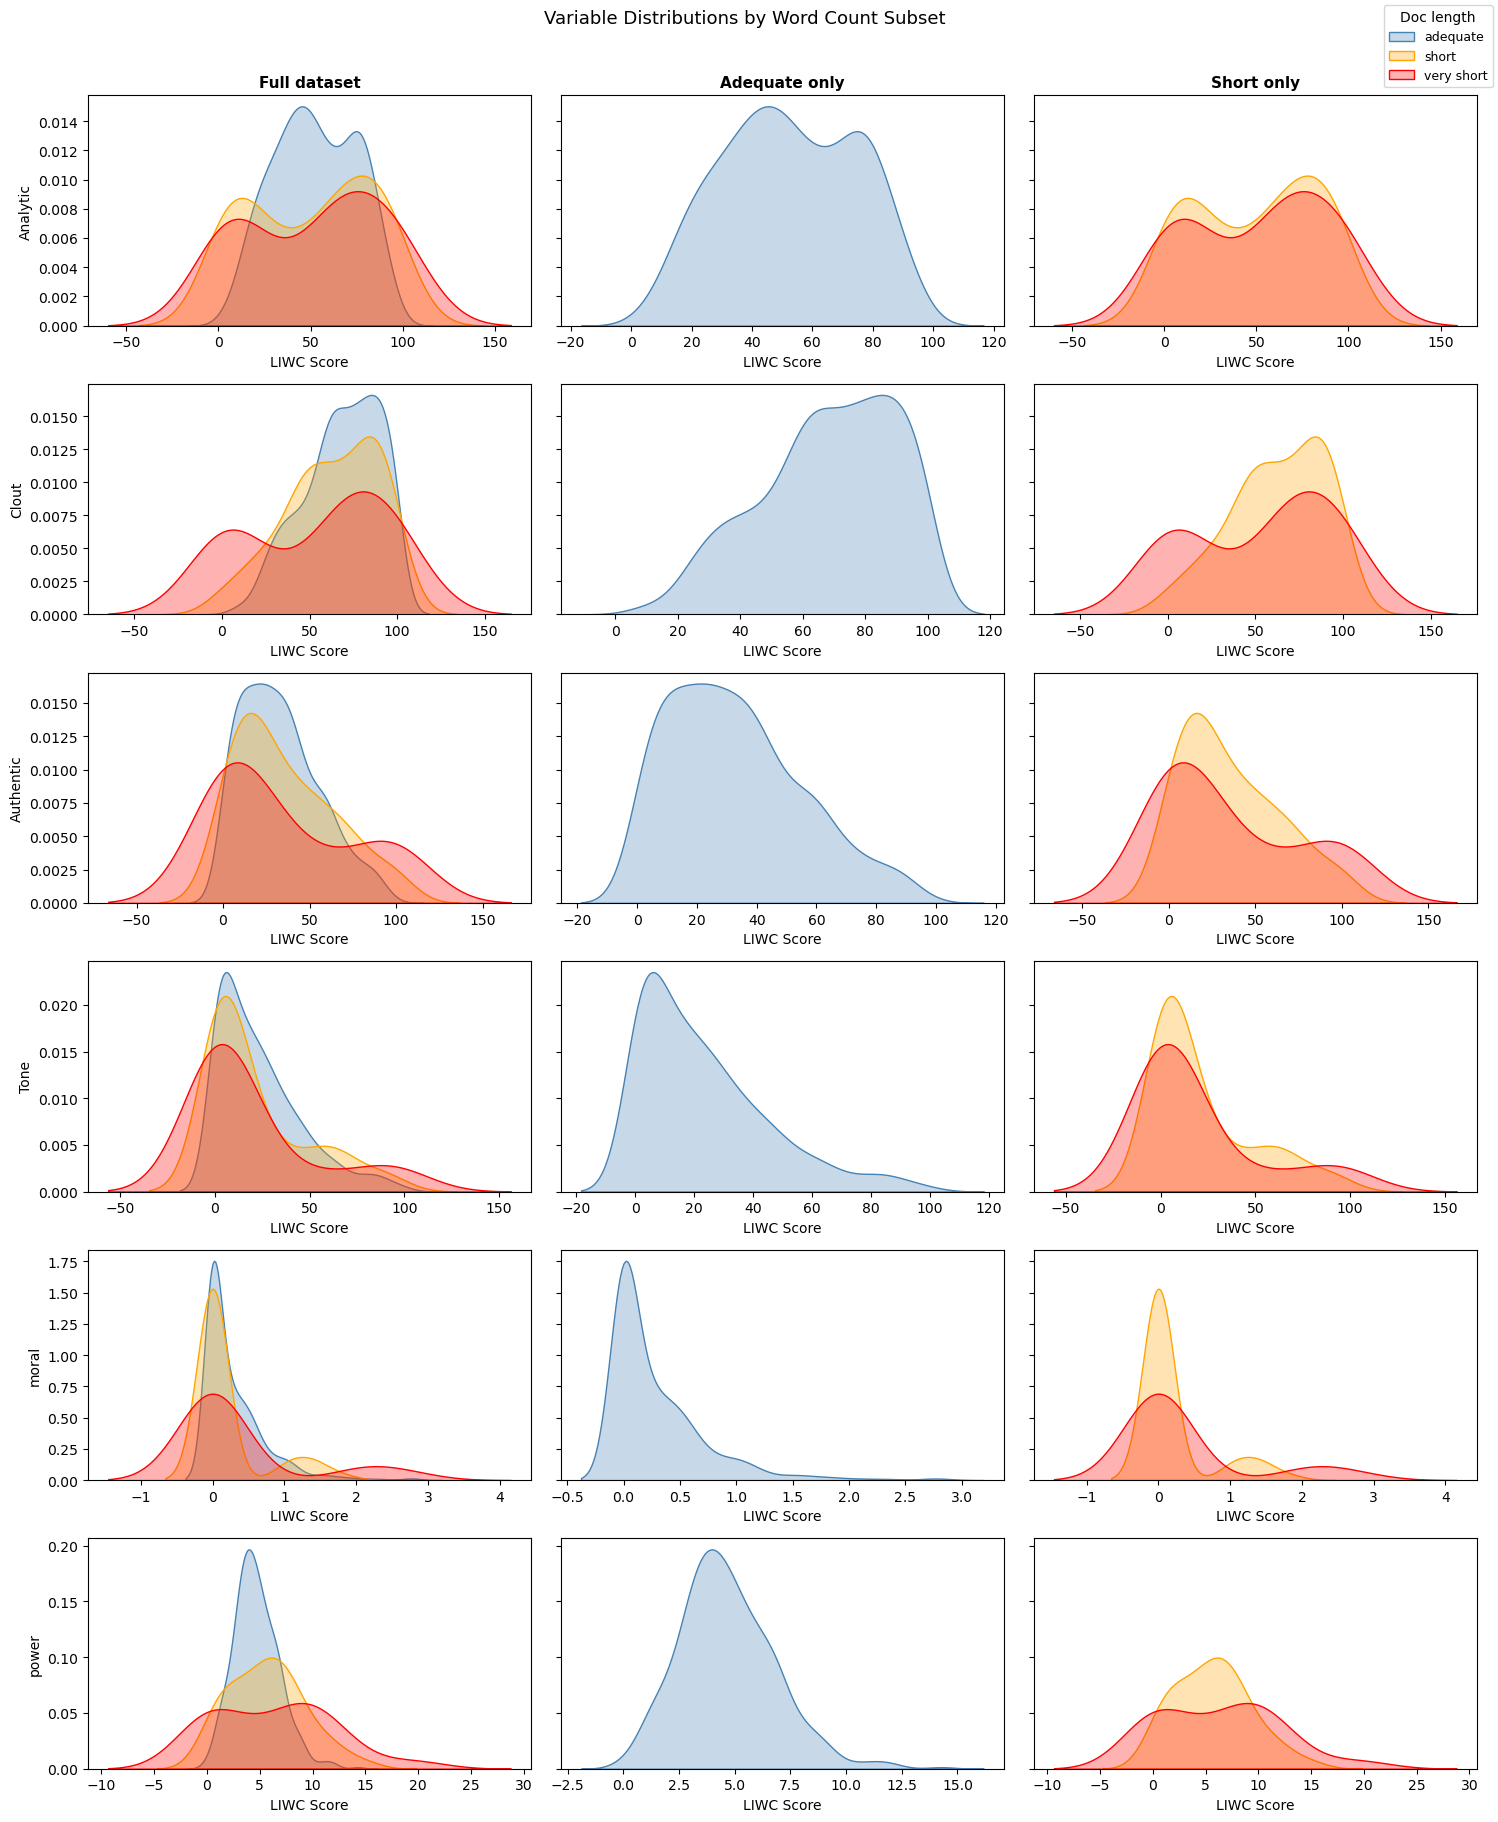

✓ Plot saved to distributions_wc_comparison.png


In [16]:
#Formalize subsets
subsets = {
    "Full dataset":  df,
    "Adequate only": df[df["wc_flag"] == "adequate"],
    "Short only":    df[df["wc_flag"] != "adequate"]
}

n_vars    = len(CORE_VARS)
n_subsets = len(subsets)

#Create plot with subplots
fig, axes = plt.subplots(
    n_vars, n_subsets,
    figsize=(5 * n_subsets, 3 * n_vars),
    sharey="row"    # share y axis scale in every row
)

#Fill in plots by row
for row, var in enumerate(CORE_VARS):
    for col, (subset_name, subset_df) in enumerate(subsets.items()):
        ax = axes[row, col]

        # plot separate KD curves for word count groups
        for wc_group, color, label in [
            ("adequate",   "steelblue", "adequate"),
            ("short",      "orange",    "short"),
            ("very_short", "red",       "very short")
        ]:
            data = subset_df[subset_df["wc_flag"] == wc_group][var].dropna()
            if len(data) >= 3:
                sns.kdeplot(data, ax=ax, color=color, label=label, fill=True, alpha=0.3)

        # Headers (top row)
        if row == 0:
            ax.set_title(subset_name, fontsize=11, fontweight="bold")

        # Vars on left column
        if col == 0:
            ax.set_ylabel(var, fontsize=10)
        else:
            ax.set_ylabel("")

        ax.set_xlabel("LIWC Score")

# Plot Legend
handles, labels = axes[0, 0].get_legend_handles_labels()
fig.legend(handles, labels, loc="upper right", title="Doc length", fontsize=9)

plt.suptitle(
    "Variable Distributions by Word Count Subset",
    fontsize=13, y=1.01
)
plt.tight_layout()
plt.show()

## Categorical Crosstab Bar Plots

# Useful for identifying confoudning variables.

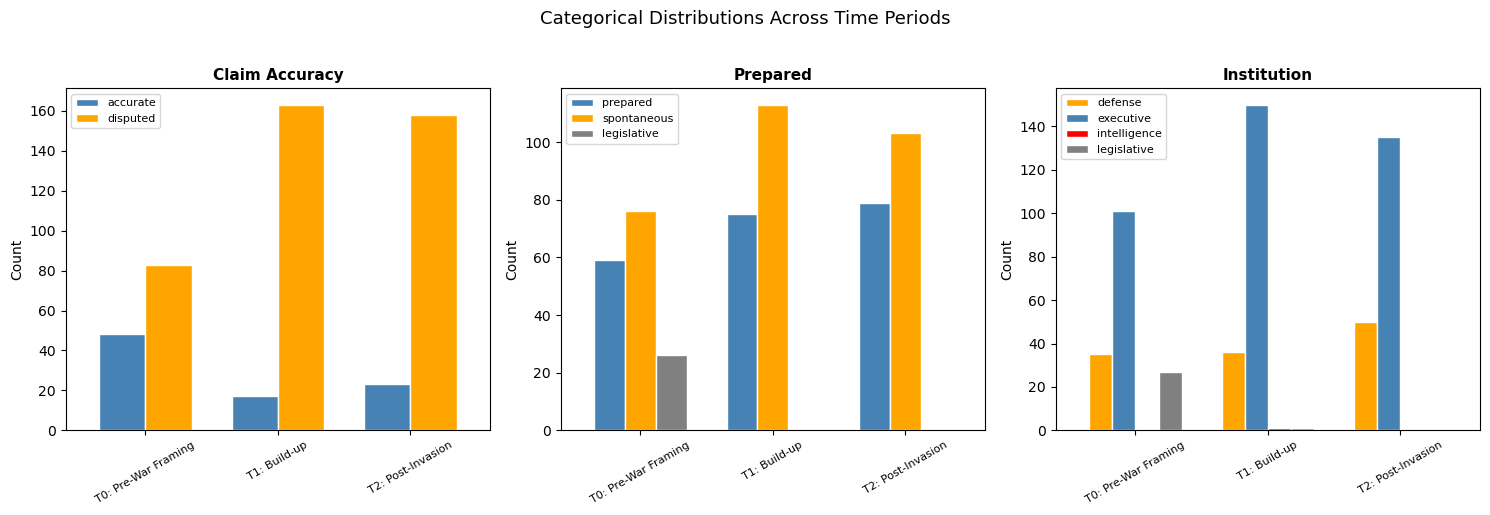

In [32]:
crosstab_vars = {
    "claim_accuracy": {"accurate": "steelblue", "disputed": "orange"},
    "prepared":       {"prepared": "steelblue", "spontaneous": "orange"},
    "institution":    {"executive": "steelblue", "defense": "orange",
                       "intelligence": "red"}
}

fig, axes = plt.subplots(1, len(crosstab_vars), figsize=(5 * len(crosstab_vars), 5))

for col, (cat, colors) in enumerate(crosstab_vars.items()):
    ax = axes[col]

    ct = (
        df.groupby(["time_period", cat], observed=True)
        .size()
        .reset_index(name="n")
        .pivot(index="time_period", columns=cat, values="n")
        .fillna(0)
    )

    ct.plot(
        kind="bar",
        ax=ax,
        color=[colors.get(c, "grey") for c in ct.columns],
        edgecolor="white",
        width=0.7
    )

    ax.set_title(cat.replace("_", " ").title(), fontsize=11, fontweight="bold")
    ax.set_xlabel("")
    ax.set_ylabel("Count")
    ax.tick_params(axis="x", rotation=30, labelsize=8)
    ax.legend(fontsize=8, title=None)

plt.suptitle(
    "Categorical Distributions Across Time Periods",
    fontsize=13, y=1.02
)
plt.tight_layout()
plt.show()


### Results Summary

Time Period: Authenticity dropped significantly as the conflict progressed, holding across both prepared and spontaneous subsets after filtering for document type (prepared or spontaneous) as a confound. The drop is most significant from T1 to T2. Power language was higher during the build-up but does not survive the prepared/spontaneous split.

Prepared vs Spontaneous: Every variable differed significantly across every dimension tested. Confirms LIWC guidance. Separate these datasets for all analysis!!

Claim Accuracy: More nuanced once split by document type. In spontaneous speech (n=70 accurate, n=215 disputed) Clout, Authentic, Tone, moral, and power all differ significantly (Analytic does not). The prepared accurate group (n=18) is too small to be conclusive. Imbalance (88 vs 404 overall) remains an invalidating concern. More data or control cases needed!

Note: From the bar graphs, we see that accurate documents are underrepresented in T0 and prepared speech is concentrated in T1 and T2. Prepared documents are also disproportionately disputed. Executive documents follow a similar pattern. These overlaps mean time period effects are partially explained by document composition. Separating prepared and spontaneous before testing time period controls for the most significant confound, and remaining overlap should be accounted for in predictive modeling.

Next Steps: Test Authenticity against a control corpus of "accurate" political speech before treating it as a reliable signal. Always separate prepared and spontaneous. Consider a Random Forest evaluated on AUC with permutation-based variable importance to identify which variables carry independent signal for accuracy classification, controlling for intercorrelation among LIWC dimensions. Consider separating by time period to see if predictive models vary.
